# Projeto - Aprendizado de Máquina
## Classificação de Custo de Seguro Saúde com Árvore de Decisão

**Objetivo:** Aplicar o algoritmo de Árvore de Decisão para classificar pacientes em "custo alto" ou "custo baixo" de seguro saúde, variando os parâmetros **critério de divisão** (Gini vs Entropia) e **profundidade máxima** da árvore.

**Base de dados:** Insurance (1.338 registros, 7 atributos)

**Técnica:** DecisionTreeClassifier (Scikit-learn)

**Variações de parâmetros:**
1. Critério de divisão: Gini vs Entropia
2. Profundidade máxima: 3, 5, 10, sem limite


## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


## 2. Carregamento e Exploração dos Dados

In [2]:
# Carregar a base de dados
insurance = pd.read_csv("insurance.csv")

print(f"Dimensões: {insurance.shape[0]} registros, {insurance.shape[1]} atributos")
print(f"\nAtributos: {list(insurance.columns)}")
print(f"\nTipos de dados:")
print(insurance.dtypes)
print(f"\nValores faltantes: {insurance.isnull().sum().sum()}")
insurance.head(10)


Dimensões: 1338 registros, 7 atributos

Atributos: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Tipos de dados:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Valores faltantes: 0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
# Estatísticas descritivas
insurance.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


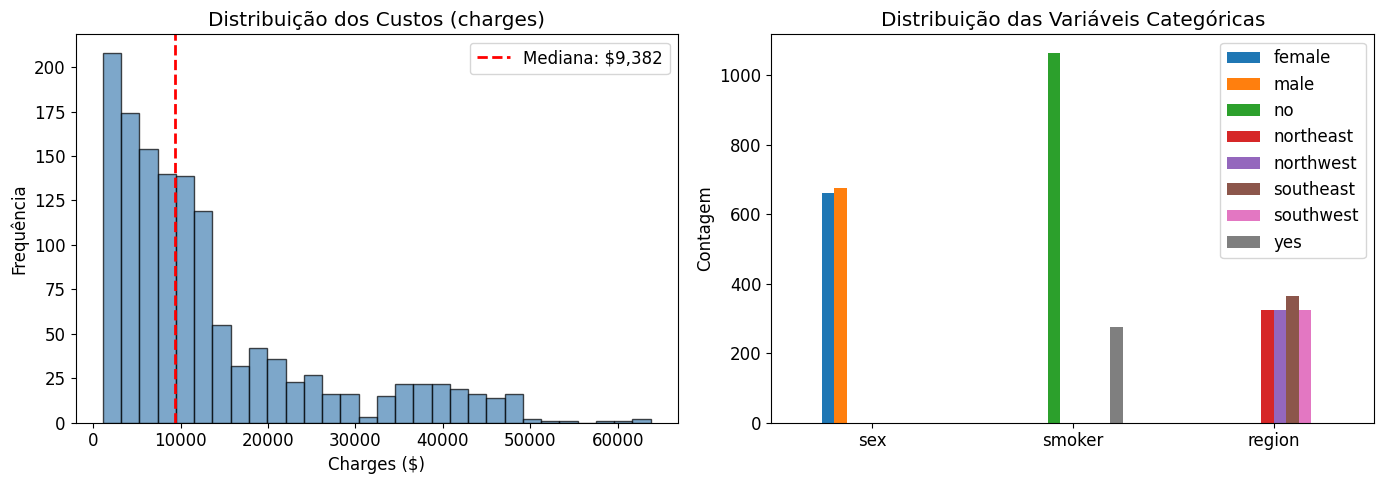

In [4]:
# Distribuição da variável alvo (charges)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(insurance['charges'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(insurance['charges'].median(), color='red', linestyle='--', linewidth=2, label=f"Mediana: ${insurance['charges'].median():,.0f}")
axes[0].set_title('Distribuição dos Custos (charges)')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Distribuição por categoria
cats = ['sex', 'smoker', 'region']
insurance[cats].apply(lambda x: x.value_counts()).T.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Distribuição das Variáveis Categóricas')
axes[1].set_ylabel('Contagem')

plt.tight_layout()
plt.show()


In [5]:
# Correlação entre variáveis numéricas
print("Matriz de correlação com charges:")
print(insurance.corr(numeric_only=True)['charges'].sort_values(ascending=False))


Matriz de correlação com charges:
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


## 3. Pré-processamento

### 3.1 Criação da variável alvo binária
Transformamos o problema de regressão em classificação: pacientes com custo acima da mediana são classificados como **"alto"** e abaixo como **"baixo"**.

### 3.2 Codificação de variáveis categóricas
Variáveis categóricas (sex, smoker, region) são convertidas para representação numérica com Label Encoding.


In [6]:
# 3.1 Criar variável alvo binária
mediana = insurance['charges'].median()
print(f"Mediana dos custos: ${mediana:,.2f}")

insurance['custo_alto'] = (insurance['charges'] > mediana).astype(int)

print(f"\nDistribuição da classe alvo:")
print(insurance['custo_alto'].value_counts())
print(f"\nProporção:")
print(insurance['custo_alto'].value_counts(normalize=True).round(3))


Mediana dos custos: $9,382.03

Distribuição da classe alvo:
custo_alto
1    669
0    669
Name: count, dtype: int64

Proporção:
custo_alto
1    0.5
0    0.5
Name: proportion, dtype: float64


In [7]:
# 3.2 Codificação de variáveis categóricas
df = insurance.copy()

# Label Encoding para variáveis binárias
df['sex'] = LabelEncoder().fit_transform(df['sex'])           # female=0, male=1
df['smoker'] = LabelEncoder().fit_transform(df['smoker'])     # no=0, yes=1

# One-Hot Encoding para região (4 categorias)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# Remover a coluna charges original (não é atributo, é a base do alvo)
df = df.drop('charges', axis=1)

print("Atributos finais:")
print(df.columns.tolist())
print(f"\nDimensões: {df.shape}")
df.head()


Atributos finais:
['age', 'sex', 'bmi', 'children', 'smoker', 'custo_alto', 'region_northwest', 'region_southeast', 'region_southwest']

Dimensões: (1338, 9)


,age,sex,bmi,children,smoker,custo_alto,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,1,False,False,True
1,18,1,33.770,1,0,0,False,True,False
2,28,1,33.000,3,0,0,False,True,False
3,33,1,22.705,0,0,1,True,False,False
4,32,1,28.880,0,0,0,True,False,False


## 4. Divisão Treino/Teste

In [8]:
# Separar atributos (X) e alvo (y)
X = df.drop('custo_alto', axis=1)
y = df['custo_alto']

# Dividir em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nDistribuição no treino: {dict(y_train.value_counts())}")
print(f"Distribuição no teste:  {dict(y_test.value_counts())}")


Treino: 936 amostras
Teste:  402 amostras

Distribuição no treino: {0: np.int64(468), 1: np.int64(468)}
Distribuição no teste:  {0: np.int64(201), 1: np.int64(201)}


## 5. Variação 1: Critério de Divisão (Gini vs Entropia)

Na teoria, aprendemos que o algoritmo de Árvore de Decisão escolhe o atributo de divisão com base em uma métrica de impureza. As duas métricas mais comuns são:

- **Gini:** `Gini(D) = 1 - Σ(p_i²)` — mais rápido de calcular
- **Entropia:** `H(D) = -Σ(p_i · log₂(p_i))` — baseado em teoria da informação

Vamos comparar o desempenho de ambos com profundidade fixa = 5.


In [9]:
# Treinar com Gini
tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
tree_gini.fit(X_train, y_train)
y_pred_gini = tree_gini.predict(X_test)

# Treinar com Entropia
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
tree_entropy.fit(X_train, y_train)
y_pred_entropy = tree_entropy.predict(X_test)

print("=" * 50)
print("CRITÉRIO GINI (profundidade = 5)")
print("=" * 50)
print(f"Acurácia: {accuracy_score(y_test, y_pred_gini):.4f}")
print(f"\n{classification_report(y_test, y_pred_gini, target_names=['Baixo custo', 'Alto custo'])}")

print("=" * 50)
print("CRITÉRIO ENTROPIA (profundidade = 5)")
print("=" * 50)
print(f"Acurácia: {accuracy_score(y_test, y_pred_entropy):.4f}")
print(f"\n{classification_report(y_test, y_pred_entropy, target_names=['Baixo custo', 'Alto custo'])}")


CRITÉRIO GINI (profundidade = 5)
Acurácia: 0.9353

              precision    recall  f1-score   support

 Baixo custo       0.90      0.99      0.94       201
  Alto custo       0.98      0.89      0.93       201

    accuracy                           0.94       402
   macro avg       0.94      0.94      0.94       402
weighted avg       0.94      0.94      0.94       402

CRITÉRIO ENTROPIA (profundidade = 5)
Acurácia: 0.9353

              precision    recall  f1-score   support

 Baixo custo       0.91      0.96      0.94       201
  Alto custo       0.96      0.91      0.93       201

    accuracy                           0.94       402
   macro avg       0.94      0.94      0.94       402
weighted avg       0.94      0.94      0.94       402



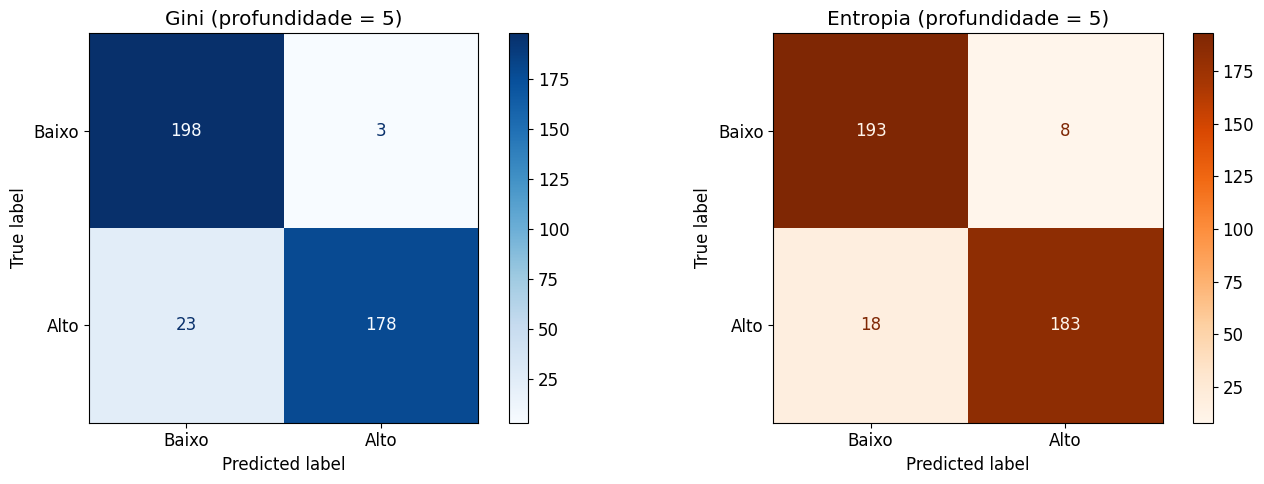

In [10]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gini, display_labels=['Baixo', 'Alto'],
                                         cmap='Blues', ax=axes[0])
axes[0].set_title('Gini (profundidade = 5)')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_entropy, display_labels=['Baixo', 'Alto'],
                                         cmap='Oranges', ax=axes[1])
axes[1].set_title('Entropia (profundidade = 5)')

plt.tight_layout()
plt.show()


## 6. Variação 2: Profundidade Máxima da Árvore

A profundidade controla a complexidade do modelo:
- **Árvore rasa** (pouca profundidade) → modelo simples → risco de **underfitting**
- **Árvore profunda** (muita profundidade) → modelo complexo → risco de **overfitting**

Vamos testar profundidades de 1 a 20 e observar o comportamento nos dados de treino e teste.


In [11]:
# Testar diferentes profundidades
depths = range(1, 21)
train_accs = []
test_accs = []

for d in depths:
    tree = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs.append(accuracy_score(y_test, tree.predict(X_test)))

# Também testar sem limite de profundidade
tree_full = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42)
tree_full.fit(X_train, y_train)
acc_train_full = accuracy_score(y_train, tree_full.predict(X_train))
acc_test_full = accuracy_score(y_test, tree_full.predict(X_test))

print(f"Sem limite de profundidade:")
print(f"  Acurácia treino: {acc_train_full:.4f}")
print(f"  Acurácia teste:  {acc_test_full:.4f}")
print(f"  Profundidade real: {tree_full.get_depth()}")


Sem limite de profundidade:
  Acurácia treino: 1.0000
  Acurácia teste:  0.8756
  Profundidade real: 21


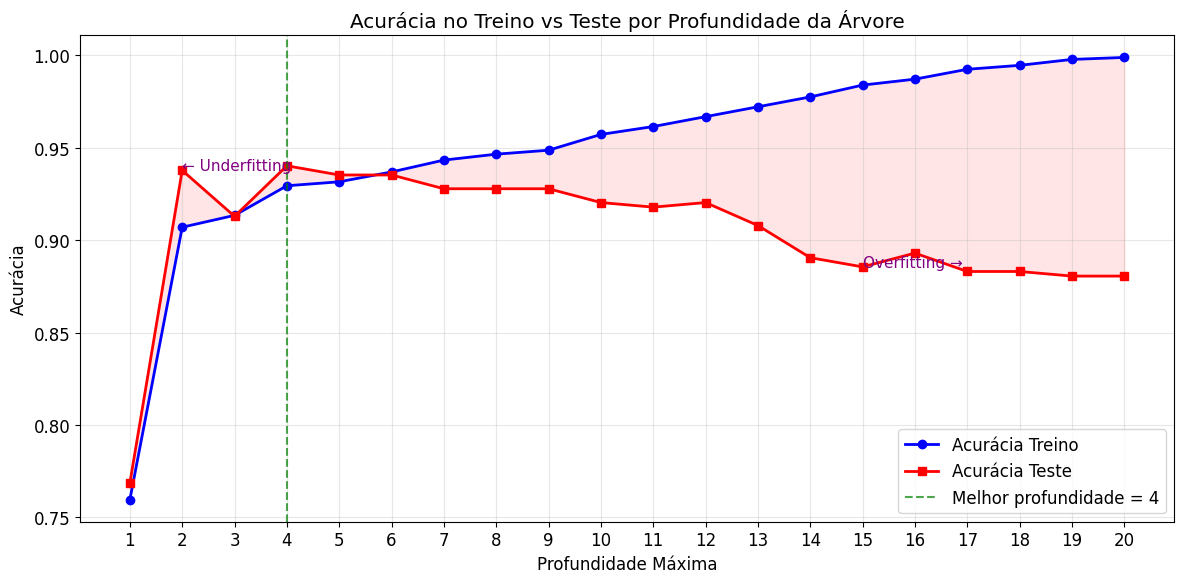


Melhor profundidade no teste: 4 (acurácia = 0.9403)


In [12]:
# Gráfico: Acurácia vs Profundidade
plt.figure(figsize=(12, 6))
plt.plot(depths, train_accs, 'o-', color='blue', label='Acurácia Treino', linewidth=2)
plt.plot(depths, test_accs, 's-', color='red', label='Acurácia Teste', linewidth=2)

# Marcar a melhor profundidade no teste
best_depth = list(depths)[np.argmax(test_accs)]
best_acc = max(test_accs)
plt.axvline(best_depth, color='green', linestyle='--', alpha=0.7, label=f'Melhor profundidade = {best_depth}')

plt.fill_between(depths, train_accs, test_accs, alpha=0.1, color='red')
plt.xlabel('Profundidade Máxima')
plt.ylabel('Acurácia')
plt.title('Acurácia no Treino vs Teste por Profundidade da Árvore')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths)

# Anotar overfitting
plt.annotate('← Underfitting', xy=(2, test_accs[1]), fontsize=11, color='purple')
plt.annotate('Overfitting →', xy=(15, test_accs[14]), fontsize=11, color='purple')

plt.tight_layout()
plt.show()

print(f"\nMelhor profundidade no teste: {best_depth} (acurácia = {best_acc:.4f})")


## 7. Modelo Final e Análise

Com base nos experimentos, treinamos o modelo final com a melhor combinação de parâmetros e analisamos os resultados.


In [13]:
# Modelo final com melhor profundidade
best_tree = DecisionTreeClassifier(criterion='gini', max_depth=best_depth, random_state=42)
best_tree.fit(X_train, y_train)
y_pred_best = best_tree.predict(X_test)

print(f"MODELO FINAL (Gini, profundidade = {best_depth})")
print("=" * 50)
print(f"Acurácia: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"\n{classification_report(y_test, y_pred_best, target_names=['Baixo custo', 'Alto custo'])}")


MODELO FINAL (Gini, profundidade = 4)
Acurácia: 0.9403

              precision    recall  f1-score   support

 Baixo custo       0.90      0.99      0.94       201
  Alto custo       0.98      0.90      0.94       201

    accuracy                           0.94       402
   macro avg       0.94      0.94      0.94       402
weighted avg       0.94      0.94      0.94       402



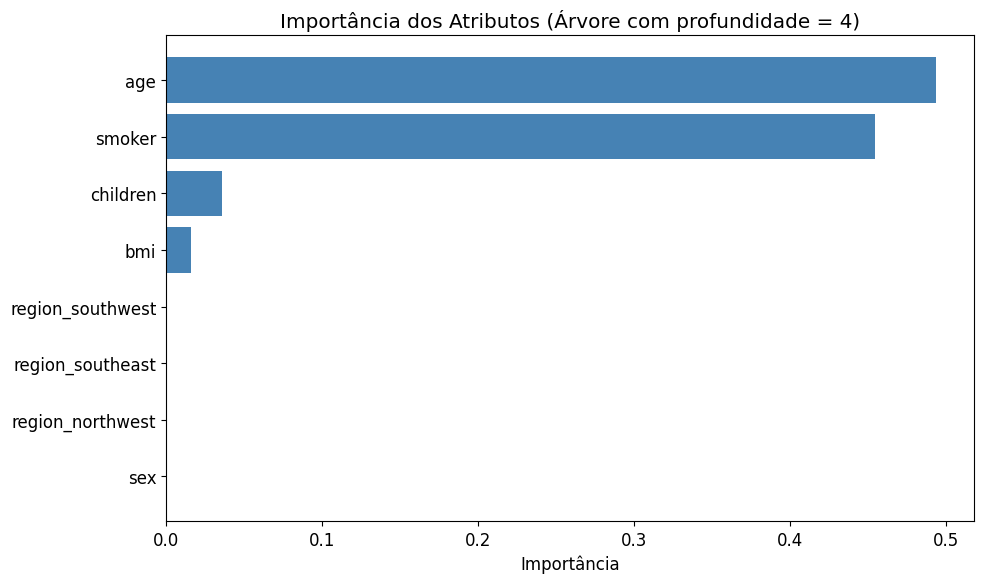


Top 3 atributos mais importantes:
  age: 0.4933
  smoker: 0.4545
  children: 0.0359


In [14]:
# Importância dos atributos
feature_importance = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importância': best_tree.feature_importances_
}).sort_values('Importância', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Atributo'], feature_importance['Importância'], color='steelblue')
plt.xlabel('Importância')
plt.title(f'Importância dos Atributos (Árvore com profundidade = {best_depth})')
plt.tight_layout()
plt.show()

print("\nTop 3 atributos mais importantes:")
for _, row in feature_importance.tail(3).iloc[::-1].iterrows():
    print(f"  {row['Atributo']}: {row['Importância']:.4f}")


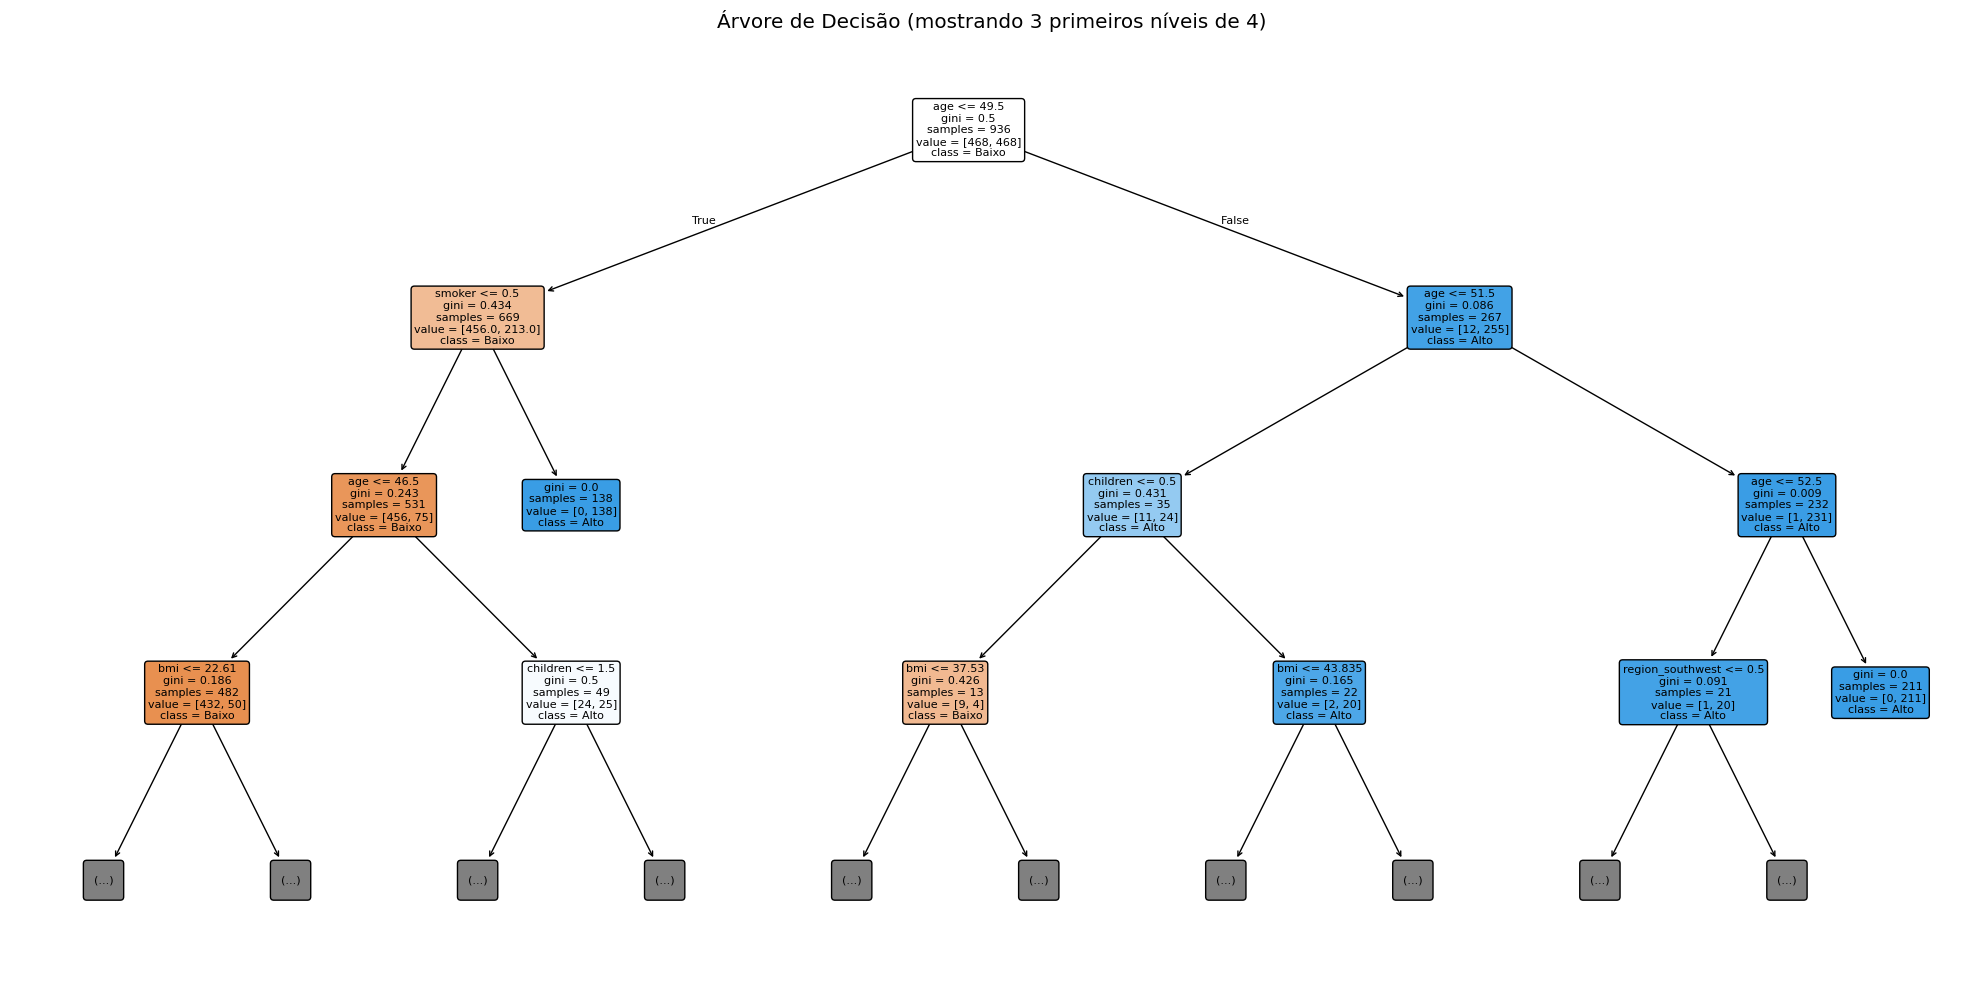

In [15]:
# Visualizar a árvore de decisão
plt.figure(figsize=(20, 10))
plot_tree(best_tree,
          feature_names=X_train.columns,
          class_names=['Baixo', 'Alto'],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3)  # Mostrar só 3 níveis para legibilidade
plt.title(f'Árvore de Decisão (mostrando 3 primeiros níveis de {best_depth})')
plt.tight_layout()
plt.show()


## 8. Tabela Comparativa dos Experimentos

In [16]:
# Tabela resumo de todos os experimentos
results = []

for criterion in ['gini', 'entropy']:
    for depth in [3, 5, 10, None]:
        tree = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        tree.fit(X_train, y_train)
        acc_train = accuracy_score(y_train, tree.predict(X_train))
        acc_test = accuracy_score(y_test, tree.predict(X_test))
        real_depth = tree.get_depth()
        results.append({
            'Critério': criterion.capitalize(),
            'Prof. Máx': depth if depth else 'Sem limite',
            'Prof. Real': real_depth,
            'Acurácia Treino': f'{acc_train:.4f}',
            'Acurácia Teste': f'{acc_test:.4f}',
            'Diferença': f'{acc_train - acc_test:.4f}'
        })

results_df = pd.DataFrame(results)
print("TABELA COMPARATIVA DE TODOS OS EXPERIMENTOS")
print("=" * 80)
print(results_df.to_string(index=False))
print("\n* Diferença alta entre treino e teste indica overfitting")


TABELA COMPARATIVA DE TODOS OS EXPERIMENTOS
Critério  Prof. Máx  Prof. Real Acurácia Treino Acurácia Teste Diferença
    Gini          3           3          0.9135         0.9129    0.0005
    Gini          5           5          0.9316         0.9353   -0.0037
    Gini         10          10          0.9573         0.9204    0.0369
    Gini Sem limite          21          1.0000         0.8756    0.1244
 Entropy          3           3          0.9081         0.9129   -0.0048
 Entropy          5           5          0.9231         0.9353   -0.0122
 Entropy         10          10          0.9605         0.9303    0.0301
 Entropy Sem limite          23          1.0000         0.8856    0.1144

* Diferença alta entre treino e teste indica overfitting


## 9. Conclusão

### Principais achados:

**Variação 1 - Critério de divisão (Gini vs Entropia):**
- Os resultados entre Gini e Entropia foram muito similares, o que é consistente com a literatura — na prática, ambos tendem a produzir árvores parecidas.
- Gini tem a vantagem de ser computacionalmente mais simples (não usa logaritmo).

**Variação 2 - Profundidade máxima:**
- Árvores muito rasas (profundidade 1-2) apresentam **underfitting**: acurácia baixa tanto no treino quanto no teste.
- Árvores muito profundas (sem limite) apresentam **overfitting**: acurácia alta no treino mas que cai no teste.
- A profundidade ideal fica num ponto intermediário, equilibrando complexidade e generalização — esse é o conceito de **poda** (pruning) visto em aula.

**Atributos mais relevantes:**
- O atributo `smoker` (fumante) é o mais importante para a classificação, o que faz sentido: fumar está fortemente associado a custos mais altos de saúde.

### Relação com a teoria:
Este projeto demonstra na prática os conceitos de **overfitting**, **underfitting** e **poda** vistos na disciplina, além de comparar as métricas **Gini** e **Entropia** para escolha de atributos na Árvore de Decisão.
